---
title: Coalescent conditioned on a derived variant
---

In [2]:
import phasic
from phasic import (
    Graph, StateIndexer, Property, SparseObservations, ExpStepSize, configure,
    GaussPrior, LogGaussPrior, BetaPrior, HalfCauchyPrior, Adamelia, dense_to_sparse,
)
import numpy as np
from itertools import combinations_with_replacement
from functools import partial
all_pairs = partial(combinations_with_replacement, r=2)
from scipy.stats import binom
from scipy.stats import beta
import matplotlib.pyplot as plt
from vscodenb import set_vscode_theme
set_vscode_theme()

In [3]:
from phasic import clear_caches
clear_caches()

In [ ]:
def coalescent_with_derived(state, indexer=None, N=None):
    transitions = []

    N = int(N) # callback params are always float

    # get nr of derived and ancestral lineages
    n_anc, n_der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            n_der += state[i]
        else:
            n_anc += state[i]
    if n_der + n_anc == 1: # absorbing state
        return []

    # available_pairs = 0
    # if n_der:
    #     available_pairs += n_der*(n_der-1)/2 
    # if n_anc:
    #     available_pairs += n_anc*(n_anc-1)/2
    # pair_correction = (n_der+n_anc)*(n_der+n_anc-1)/2 / available_pairs

    # pop derived freq
    freq = int(state[indexer.derived_freq])

    assert n_der <= freq < N, f"invalid state: {state}, n_der={n_der}, freq={freq}, N={N}"
    assert n_anc <= N-freq <= N, f"invalid state: {state}, n_anc={n_anc}, N-freq={N-freq}, N={N}"

    # coalescence transitions
    for i, j in all_pairs(range(indexer.lineages.state_length)):

        same_kind = int(i == j)
        # if same_kind and state[i] < 2:
        #     continue
        # if not same_kind and (state[i] < 1 or state[j] < 1):
        #     continue

        # props of lineage types at index i and j
        pi = indexer.lineages.i2p(i)
        pj = indexer.lineages.i2p(j)
        # nr of lineage pairs
        pair_count = state[i] * (state[j] - same_kind) / (1 + same_kind)
        if not pair_count:
            # there must be at least 2 lineages for a coalescence
            continue

        if n_der > 1 and bool(pi.is_derived) == bool(pj.is_derived): # same ancestry
            if pi.is_derived:
                # coal of two der lineages
                new = state.copy()
                new[i] -= 1
                new[j] -= 1
                is_derived = pi.is_derived
                k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=is_derived)
                new[k] += 1
                new[indexer.derived_freq] = freq
                # rate = freq*(1+s)/(N+s*freq) * freq/(N) *  pair_count/(freq*(freq-1)/2) * N/2/freq 
                # rate = freq*(1+s)/(N+s*freq) * 1/(N) *  pair_count
                # rate = freq*(1+s)/(N+s*freq) * 1/(N) *  pair_count * pair_count/(freq*(freq-1)/2)

                # think this is right:
                # rate = freq*(1+s)/(N+s*freq) * freq/(N) * 2/freq**2 * pair_count
                # same as:                                          # account for anc/der constraints allowing fewer pairs
                rate = (1+s)/(N+s*freq) * 1/(N) * 2 * pair_count    * (n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2)
                # print((n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2))

                transitions.append([new, rate])
            else:
                # coal of two anc lineages
                new = state.copy()
                new[i] -= 1
                new[j] -= 1
                is_derived = pi.is_derived
                k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=is_derived)
                new[k] += 1
                new[indexer.derived_freq] = freq
                # rate = (N-freq)/(N+s*freq) * (N-freq)/(N) * pair_count/((N-freq)*((N-freq)-1)/2) * N/2/(N-freq) 
                # rate = 2/N**2 * pair_count

                # think this is right:
                # rate = (N-freq)/(N+s*freq) * (N-freq)/(N) * 2/(N-freq)**2 * pair_count
                # same as:                                          # account for anc/der constraints allowing fewer pairs
                rate = 1/(N+s*freq) * 1/(N) * 2 * pair_count        * (n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2)
                # print("A", pair_count, (n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2))

                transitions.append([new, rate])
        # elif freq <= 1:
        elif n_der <= 1:
            # coal of one anc and the last der lineage (also sets freq go zero)
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            is_derived = 0
            k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=is_derived)
            new[k] += 1
            new[indexer.derived_freq] = freq if bool(pi.is_derived) == bool(pj.is_derived) else 0
            # rate = 2/N**2 * (n_der+n_anc)*(n_der+n_anc-1)/2  # *pair_count
            rate = 2/N**2 * pair_count
            # print("AD", pair_count, (n_der+n_anc)*(n_der+n_anc-1)/2)

            # print(rate, pair_count)
            # print(pi.is_derived, pj.is_derived, freq, pair_count, rate, new)
            transitions.append([new, rate])

    if n_der <= freq - 1 and 0 < freq < N:
        # der birth, anc death (freq decrease backwards in time)
        new = state.copy()
        new[indexer.derived_freq] = freq - 1
        rate = freq*(1+s)/(N+s*freq) * (N-freq)/N
        transitions.append([new, rate])

    if n_anc <= N-(freq+1) and 0 < freq < N-1:
        # anc birth, der death (freq increase backwards in time)
        new = state.copy()
        new[indexer.derived_freq] = freq + 1

        rate = (N-freq)/(N+s*freq) * freq/N
        transitions.append([new, rate])

    return transitions


N = 10
s = 0
# n_ancestral = 3
# n_derived = 1
# n_ancestral = 1
# n_derived = 3

n_ancestral = 2
n_derived = 2

# n_ancestral = 2
# n_derived = 1
# n_ancestral = 1
# n_derived = 2

n_samples = n_ancestral + n_derived
assert n_ancestral > 0 

indexer = StateIndexer(
    "derived_freq",
    lineages=[
        Property('descendants', min_value=1, max_value=max(n_samples, n_derived)),        
        Property('is_derived', min_value=0, max_value=1),        
        ],
)

ipv = []
freqs = np.arange(n_derived, N-n_ancestral+1, dtype=int)
p = freqs / N
rates = beta(1 + n_derived, 1 + (n_samples - n_derived)).pdf(p)
# rates = beta(1/2 + n_derived, 1/2 + (n_samples - n_derived)).pdf(p)
rates /= rates.sum()

# ####################################################
# rates = np.zeros(len(freqs), dtype=int)
# rates[0] = 1
# ####################################################

#############
rates = rates / (np.sum(rates) + 1e-15)
#############

# ####################################################
# rates = np.ones(len(freqs), dtype=int)
# rates = rates / (np.sum(rates) + 1e-15)
# ####################################################

for i in range(len(freqs)):
    state = [0] * indexer.state_length
    state[indexer.lineages.props_to_index(descendants=1, is_derived=0)] = n_samples - n_derived
    state[indexer.lineages.props_to_index(descendants=1, is_derived=1)] = n_derived
    state[indexer.derived_freq] = freqs[i]
    if rates[i]:
        ipv.append([state, rates[i]])


ax = plt.subplot(111)
ax.scatter(freqs, rates)
ax.vlines(freqs, ymin=0, ymax=rates)
ax.set_title('Beta IPV')

with configure(parallel_elimination=False, reward_compute_cache=False, graph_cache=False):
    graph = Graph(coalescent_with_derived, ipv=ipv, indexer=indexer, N=N)

print(graph.expectation() * 2/N)

def node_label(vertex):
    n_anc, n_der = 0, 0
    state = vertex.state()
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            n_der += state[i]
        else:
            n_anc += state[i]
    return f'a:{n_anc}, d:{n_der}, f:{state[indexer.derived_freq]}'

graph.plot(ranksep=5, nodesep=1, #fontsize=15,
    subgraphfun=lambda state: str(state[:-1]), label_fmt=node_label,
    #label_fmt=lambda v: f'{v.index()}',
    color_by = graph.expected_sojourn_time(), color_by_cmap='rainbow', # color_by_lim=(0, None),
    size=(15, 15), #max_nodes=500,
    )

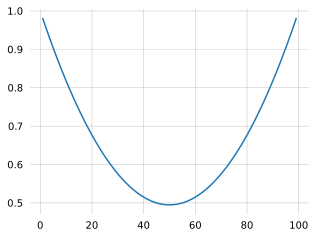

In [140]:
N = 100
n = np.arange(1, N)
plt.plot(n, (n*(n-1)/2 + (N-n)*(N-n-1)/2) / (N*(N-1)/2)) ;

In [158]:
1 / 0.0222222222 * 2 / N

9.000000009

In [155]:
1/9

0.1111111111111111

In [38]:
9 * N/2

45.0

In [60]:
clear_caches()

In [61]:
import numpy as np

# # --- parameters ---
# N = 100
# n_ancestral = 1
# n_derived   = 1
# n_samples   = n_ancestral + n_derived
# s = 0.2

def simulate_loss_times(N, s, p0_draws, rng, max_gen=10_000_000):
    """Forward haploid Wright-Fisher with selection (derived fitness 1+s).
    Runs each replicate to absorption (vectorized over replicates).
    Returns (times, outcome): outcome 0 = derived lost, 1 = derived fixed."""
    counts  = np.clip(np.rint(p0_draws * N).astype(np.int64), 1, N - 1)
    t       = np.zeros(counts.shape, dtype=np.int64)
    outcome = np.full(counts.shape, -1, dtype=np.int8)   # -1 = still segregating
    active  = np.ones(counts.shape, dtype=bool)

    for _ in range(max_gen):
        idx = np.flatnonzero(active)
        if idx.size == 0:
            break
        p     = counts[idx] / N
        p_sel = p * (1 + s) / (1 + s * p)                # selection on derived
        new   = rng.binomial(N, p_sel)                   # binomial resampling
        counts[idx] = new
        t[idx] += 1
        lost, fixed = (new == 0), (new == N)
        outcome[idx[lost]]  = 0
        outcome[idx[fixed]] = 1
        active[idx[lost | fixed]] = False

    return t, outcome

# --- draw starting frequencies from the posterior, simulate, keep only losses ---
rng = np.random.default_rng(0)
R   = 500_000
p0  = rng.beta(1 + n_derived, 1 + (n_samples - n_derived), size=R)   # posterior
# p0 = np.repeat(rates, 1000)

t, outcome = simulate_loss_times(N, s, p0, rng)

loss      = outcome == 0
mean_loss = t[loss].mean()
se        = t[loss].std(ddof=1) / np.sqrt(loss.sum())

print(f"loss fraction          : {loss.mean():.3f}")
print(f"E[T_loss | data, loss] : {mean_loss:.2f}  ± {se:.2f}  (n_loss = {loss.sum():,})")

loss fraction          : 0.501
E[T_loss | data, loss] : 11.12  ± 0.02  (n_loss = 250,698)


In [40]:
import numpy as np
from scipy.stats import beta

# --- parameters ---
# N = 100
# n_samples = 3
# n_derived = 1
# s = 0.0                      # selection coeff on derived allele (haploid fitness 1+s)
gamma = 2 * N * s             # scaled selection coefficient (haploid: 2Ns)

# --- posterior over the current/starting frequency (uniform prior) ---
k = np.arange(1, N)
p = k / N
w = beta(1 + n_derived, 1 + (n_samples - n_derived)).pdf(p)
w /= w.sum()

# --- fixation probability under selection (Kimura) ---
def u_fix(x, gamma):
    x = np.asarray(x, dtype=float)
    if abs(gamma) < 1e-12:
        return x.copy()
    return (1.0 - np.exp(-gamma * x)) / (1.0 - np.exp(-gamma))

# --- conditional mean loss time t0(p), haploid N, via Green's function ---
def cond_loss_time(p_val, N, gamma, n_grid=4000):
    x   = np.arange(1, n_grid) / n_grid           # interior (0,1)
    u   = u_fix(x, gamma)
    up  = u_fix(np.array([p_val]), gamma)[0]
    V   = x * (1 - x) / N
    psi = np.exp(-gamma * x)
    I   = (1 - np.exp(-gamma)) / gamma if abs(gamma) > 1e-12 else 1.0
    G = np.where(x > p_val,
                 2 * I * up * (1 - u) / (V * psi),    # start below x
                 2 * I * u  * (1 - up) / (V * psi))   # start above x
    return np.trapezoid(G * (1 - u), x) / (1 - up)

# --- evaluate on posterior grid ---
t0        = np.array([cond_loss_time(pi, N, gamma) for pi in p])
loss_prob = 1 - u_fix(p, gamma)

# average over posterior AND condition on loss
E_loss = np.sum(w * loss_prob * t0) / np.sum(w * loss_prob)
print("E[T_loss | data, loss]:", E_loss)

E[T_loss | data, loss]: 11.771231510497135


In [11]:
s = 0.1
N = 10
freq = 1
freq * (N - freq) / (N * (N+s*freq)), (1 + s) * freq * (N - freq) / (N * (N+s*freq))

(0.0891089108910891, 0.09801980198019802)

In [12]:
freq * (N - freq) / (N * (N+s*freq)), (1 + s) * freq * (N - freq) / (N * (N+s*freq))

(0.0891089108910891, 0.09801980198019802)

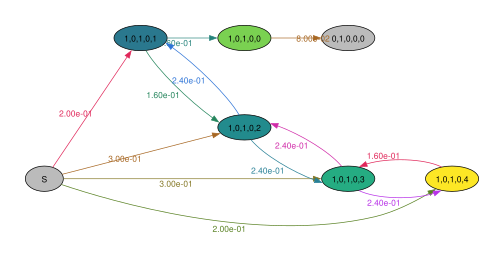

In [13]:
graph.plot(max_nodes=300)

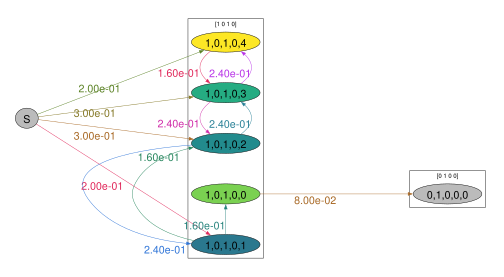

In [14]:
graph.plot(
    subgraphfun=lambda state: str(state[:-1]),
    ranksep=5, fontsize=25,
    )

In [15]:
n = 5
t = 0
for i in range(2, n):
    t += 2 * N / (i*(i-1))
    print(i, t)

2 10.0
3 13.333333333333334
4 15.0


In [16]:

f = n_derived / n_samples
-N*f/(1-f)*np.log(f)

np.float64(6.931471805599453)

In [17]:
graph.vertices_length()

7

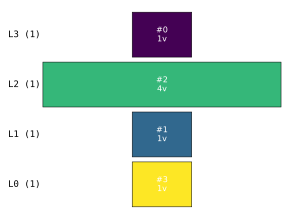

In [18]:
graph.plot_scc_decomp();

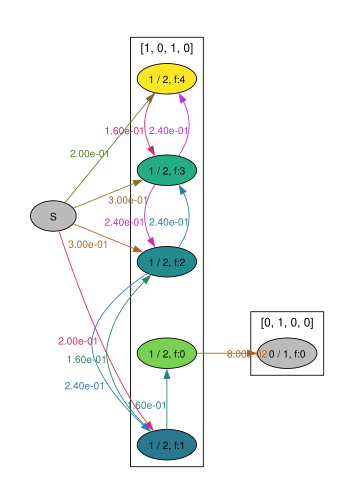

In [19]:

def label(vertex):
    state = vertex.state()
    anc, der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            der += state[i]
        else:
            anc += state[i]
    return f'{der} / {anc+der}, f:{state[indexer.derived_freq]}'

def subgr(state):
    s = state.tolist()
    del s[indexer.derived_freq]
    return s

graph.plot(subgraphfun=subgr, label_fmt=label)

In [20]:
graph = cont_graph.discretize(rate=mutation_rate)

def weight_update(param, coef):
    N, s, u = param
    coal_rate_scalar, from_freq, to_freq, mut_scalar = coef

    if coal_rate_scalar > 0:
        return coal_rate_scalar / N
    elif mut_scalar:
        return u * mut_scalar
    else:
        _s = - s # s is negative because time is backwards
        N = int(round(N)) # binom.pmf wants integer N
        sampling_prob = from_freq/N * (1 + _s) / (1 + _s * from_freq/N)
        rate = binom.pmf(to_freq, N, sampling_prob)
        return rate

graph.update_weights(true_theta + [mutation_rate], callback=weight_update)
graph.plot()

NameError: name 'cont_graph' is not defined

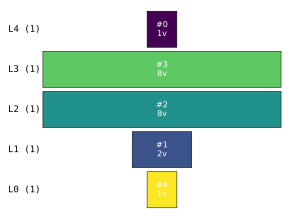

In [ ]:
graph.plot_scc_decomp();

In [ ]:
# with configure(parallel_elimination=True):
#     # cache parameterized reward compute for graph and its SCCs
#     graph.prewarm_cache()

In [ ]:
graph.rewards

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
rewards = np.array(graph.states()).T
rewards[:, -1] = 0 # zero out absorbing
rewards[np.sum(rewards, axis=1) > 0] # only indexer slot representing actual states used

array([[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 2, 3, 4, 1, 2, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int32)

In [ ]:

nr_observations = 1000
n = nr_observations
observed_data = np.zeros((n * (rewards.shape[0]), rewards.shape[0]), dtype=float)
observed_data[:] = np.nan
for i in range(rewards.shape[0]):
    observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])
np.random.shuffle(observed_data)
observed_data[:nr_observations] # just the first nr_observations rows
sparse_observations = dense_to_sparse(observed_data)
sparse_observations

RuntimeError: Expected vertex with index 3 (state 1 0 0 2 0 0 3) to have outgoing rate <= 1. Is '1.163525'. Are you sure this is a discrete phase-type distribution?


In [ ]:
#%%monitor
phasic.set_log_level('DEBUG')
svgd = graph.svgd(
    observed_data=sparse_observations, 
                  rewards=rewards, 
                  preconditioner='none',
                  callback=weight_update,
                  theta_dim=2,
                  fixed=[(0, pop_size)],
                  prior=[
                      None,
                      BetaPrior(ci=(0.01, 0.5)),
                  ],
                  n_iterations=20,                
                  n_particles=50,                
                learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0),
                progress=True,
                      )                  

[DEBUG] phasic.c: Auto-selected granularity: 1024 (max_rate=512.00)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e+18 (576 ill-conditioned operations)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e+18 (576 ill-conditioned operations)
[DEBUG] phasic.svgd: SVGD.optimize: no preconditioner configured
[DEBUG] phasic.c: Auto-selected granularity: 1024 (max_rate=512.00)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e+18 (428 ill-conditioned operations)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e

In [ ]:
svgd.summary()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_pairwise()

### No epochs joint prob

In [ ]:
joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit)
print(joint_graph.vertices_length())
joint_graph.plot(max_nodes=400, nodesep=0.2, ranksep=3, by_state=subgr)

In [ ]:
def sample_joint_observations(joint_graph, theta, nr_observations):
    joint_graph.update_weights(theta + [mutation_rate], callback=weight_update) 
    joint_prob_table = joint_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

In [ ]:
observations = sample_joint_observations(joint_graph, true_theta + [mutation_rate], nr_observations=10000)
observations[:5]

In [ ]:
svgd = joint_graph.svgd(
    observed_data=observations, 
                  callback=weight_update,
                  theta_dim=3,
                #   fixed=[(2, mutation_rate)],
                #   prior=[
                #       GaussPrior(ci=[1, 5]),  
                #       HalfCauchyPrior(ci=0.3),
                #       None
                #   ],
                  n_iterations=20,                
                  n_particles=50,                
            # learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0)
                 optimizer=Adamelia(learning_rate=0.2)
                      )



In [ ]:
svgd.summary()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_pairwise()

In [ ]:

jp_graph = graph.joint_prob_graph(indexer, 
                                  reward_limit=reward_limit, 
                                  mutation_rate=mutation_rate)
jp_graph.update_weights(true_theta + [mutation_rate], callback=weight_update)
joint_prob_table = jp_graph.joint_prob_table()
(1 - joint_prob_table['prob'].sum()).item()

In [ ]:
jp_graph = graph.joint_prob_graph(indexer, 
                                  reward_limit=reward_limit, 
                                  mutation_rate=mutation_rate)
jp_graph.update_weights(true_theta + [mutation_rate])
joint_prob_table = jp_graph.joint_prob_table()
(1 - joint_prob_table['prob'].sum()).item()

In [ ]:

def sample_joint_observations(joint_prob_graph, theta, nr_observations):
    joint_prob_graph.update_weights(theta) 
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

observations = sample_joint_observations(jp_graph, true_theta + [mutation_rate], nr_observations=10000)
observations[:5]


In [ ]:
nr_observations = 10000
observed_data = graph.sample(nr_observations, rewards=rewards)
observed_data

In [ ]:
%%monitor

svgd = joint_prob_graph.svgd(
    observed_data=observations, 
    callback=weight_update,
    # fixed=[(2, mutation_rate)],
    # n_iterations=100,
    # n_particles=200,
    # prior=[
    #     GaussPrior(ci=[5, 25]),
    #     GaussPrior(ci=[0, 3]),
    #     None
    # ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
    )

svgd.summary()